# 🔬 Experiment Set 1 — Numeric Sensitivity Test
## Gap 2: SBERT Fails on Numeric Perturbations, Hybrid Succeeds

---

## Dataset Used: `rfp_specs_numeric_perturbation.csv` (Variant 6)

**Why this dataset and NOT the others:**

| Dataset | Why NOT used here |
|---|---|
| Clean base | Baseline already established in Obj 1 — not a stress test |
| In-domain noise | Tests robustness to filler text, not numeric reasoning |
| Out-of-domain noise | Tests topic confusion, not numeric reasoning |
| Long-doc | Tests attention over long sequences, not numeric reasoning |
| Positional shift | Tests where in the text the spec appears, not number changes |
| Missing specs | Tests incomplete information, not wrong numbers |
| **✅ Numeric Perturbation** | **Directly tests whether models can distinguish `11kV` from `33kV`, `3C` from `4C`, `240sqmm` from `185sqmm` — exactly Experiment Set 1's goal** |
| Unit variation | Tests notation (`kV` vs `V`, `sqmm` vs `mm²`) not value changes |

## What Was Perturbed
Only `spec_text_raw` is changed. All **structured columns** (`voltage_rating`, `core_count`, `size_sqmm`, etc.) **remain at their original correct values**.

This creates the perfect controlled experiment:
- **SBERT** reads `spec_text_raw` → sees wrong numbers → **assigns high similarity anyway** (SBERT doesn't reason over numbers)
- **Hybrid** uses structured columns for its structured score → sees the correct labels → **correctly flags or scores compliance**
- **Numeric Accuracy** = does the model detect that the text says `33kV` when the label says `11kV`?

## Metrics
1. **Numeric Accuracy** — did the top-1 retrieved SKU match on all perturbed numeric fields?
2. **Compliance Accuracy** — did the compliance score correctly drop for perturbed inputs vs clean inputs?
3. **Score Degradation (ΔScore)** — how much does each model's score drop when numbers are wrong?
4. **Rank Stability** — does the correct SKU fall out of Top-5 when numbers are perturbed?
5. **All standard IR metrics** — Top-1, Top-5, MRR, NDCG@5 on perturbed data vs clean baseline

In [ ]:
# ============================================================
# CELL 1 — INSTALL
# ============================================================
!pip install -q sentence-transformers scikit-learn rank-bm25 pandas numpy matplotlib tabulate pyarrow

In [ ]:
# ============================================================
# CELL 2 — IMPORTS
# ============================================================
import os, json, re, time, warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
from typing import Dict, List, Optional, Tuple

from sklearn.feature_extraction.text import TfidfVectorizer
from sentence_transformers import SentenceTransformer
from rank_bm25 import BM25Okapi

warnings.filterwarnings('ignore')
np.random.seed(42)

ARTIFACT_DIR = 'obj1_model_artifacts'   # folder saved at end of Objective 1
EXP_DIR      = 'exp1_numeric_sensitivity'
os.makedirs(EXP_DIR, exist_ok=True)

print('✅ Imports done.')

✅ Imports done.


In [ ]:
# ============================================================
# CELL 3 — LOAD OBJ 1 ARTIFACTS + EXPERIMENT DATASETS
# Upload to Colab:
#   obj1_model_artifacts/   (entire folder from Obj 1)
#   rfp_specs_7000.csv                    (clean baseline)
#   rfp_specs_numeric_perturbation.csv    (Variant 6 — THIS experiment)
#   product_catalog.csv
# ============================================================

# ── Load Obj 1 artifacts ─────────────────────────────────────
cfg         = json.load(open(f'{ARTIFACT_DIR}/model_config.json'))
product_df  = pd.read_parquet(f'{ARTIFACT_DIR}/product_df.parquet')
rfp_gt_df   = pd.read_parquet(f'{ARTIFACT_DIR}/rfp_df_with_gt.parquet')   # ground truth from Obj 1
product_emb = np.load(f'{ARTIFACT_DIR}/product_embeddings_mpnet.npy')     # shape (200, 768)

# Obj 1 baseline scores for comparison
baseline_df = pd.read_csv(f'{ARTIFACT_DIR}/baseline_results.csv')

# ── Load experiment datasets ─────────────────────────────────
df_clean = pd.read_csv('rfp_specs_7000.csv').reset_index(drop=True)
df_num   = pd.read_csv('rfp_specs_numeric_perturbation.csv').reset_index(drop=True)

df_clean.columns = df_clean.columns.str.strip()
df_num.columns   = df_num.columns.str.strip()
product_df.columns = product_df.columns.str.strip()

# Ground truth lookup from Obj 1 (same RFP IDs, same SKU assignments)
gt_lookup = (
    rfp_gt_df
    .dropna(subset=['ground_truth_sku'])
    .drop_duplicates('rfp_id')
    .set_index('rfp_id')['ground_truth_sku']
    .to_dict()
)

N_RFP = len(df_clean)
N_SKU = len(product_df)
K     = cfg['K']

print(f'Product catalog      : {product_df.shape}')
print(f'Clean RFP specs      : {df_clean.shape}')
print(f'Perturbed RFP specs  : {df_num.shape}')
print(f'GT entries           : {len(gt_lookup)}')
print(f'K                    : {K}')
print(f'Hybrid weights       : {cfg["hybrid_weights"]}')
print(f'\nObj 1 baseline results (for comparison later):')
print(baseline_df[['Model','Top-1 Acc','MRR','NDCG@5']].to_string(index=False))

Product catalog      : (200, 16)
Clean RFP specs      : (7000, 17)
Perturbed RFP specs  : (7000, 17)
GT entries           : 7000
K                    : 5
Hybrid weights       : {'structured': 0.5, 'semantic': 0.3, 'standards': 0.2}

Obj 1 baseline results (for comparison later):
                    Model  Top-1 Acc      MRR   NDCG@5
       1. Random Baseline   0.004571 0.029806 0.016021
       2. TF-IDF + Cosine   0.115429 0.231303 0.220847
          3. BM25 (Okapi)   0.055857 0.165056 0.148266
       4. SBERT MiniLM-L6   0.132571 0.231357 0.231525
5. SBERT MPNet (sem-only)   0.165286 0.260932 0.248361
6. Exact Structured Match   0.057000 0.129356 0.116747
       7. 🏆 Hybrid (Ours)   0.178000 0.308767 0.312451


In [ ]:
# ============================================================
# CELL 4 — PERTURBATION ANALYSIS
# Understand exactly what changed between clean and perturbed
# ============================================================
VOLTAGE_PAT = r'\b(\d+(?:\.\d+)?(?:kV|V))\b'
CORE_PAT    = r'\b(\d+)C\b'
SIZE_PAT    = r'\b(\d+(?:\.\d+)?)\s*sqmm\b'

perturb_types = []
for i in range(N_RFP):
    orig = str(df_clean.loc[i, 'spec_text_raw'])
    pert = str(df_num.loc[i, 'spec_text_raw'])

    v_changed = re.findall(VOLTAGE_PAT, orig) != re.findall(VOLTAGE_PAT, pert)
    c_changed = re.findall(CORE_PAT,   orig) != re.findall(CORE_PAT,   pert)
    s_changed = re.findall(SIZE_PAT,   orig) != re.findall(SIZE_PAT,   pert)

    perturb_types.append({
        'rfp_id':          df_clean.loc[i, 'rfp_id'],
        'voltage_changed': v_changed,
        'core_changed':    c_changed,
        'size_changed':    s_changed,
        'n_changes':       sum([v_changed, c_changed, s_changed]),
        'orig_text':       orig,
        'pert_text':       pert,
    })

pert_df = pd.DataFrame(perturb_types)
n_total = len(pert_df)

print('=== Perturbation Breakdown ===')
print(f'Voltage changed   : {pert_df.voltage_changed.sum():5d}  ({pert_df.voltage_changed.mean()*100:.1f}%)')
print(f'Core changed      : {pert_df.core_changed.sum():5d}  ({pert_df.core_changed.mean()*100:.1f}%)')
print(f'Size changed      : {pert_df.size_changed.sum():5d}  ({pert_df.size_changed.mean()*100:.1f}%)')
print(f'2+ fields changed : {(pert_df.n_changes>=2).sum():5d}  ({(pert_df.n_changes>=2).mean()*100:.1f}%)')
print(f'All 3 changed     : {(pert_df.n_changes==3).sum():5d}  ({(pert_df.n_changes==3).mean()*100:.1f}%)')
print()
print('--- Sample perturbations ---')
for _, row in pert_df[pert_df.n_changes >= 2].head(5).iterrows():
    print(f'  ORIG : {row.orig_text}')
    print(f'  PERT : {row.pert_text}')
    print()

=== Perturbation Breakdown ===
Voltage changed   :  4699  (67.1%)
Core changed      :  4690  (67.0%)
Size changed      :  4667  (66.7%)
2+ fields changed :  4689  (67.0%)
All 3 changed     :  2367  (33.8%)

--- Sample perturbations ---
  ORIG : FRLS 3.3kV 1C 50 sqmm Cu EPR armoured cable as per IS 7098-1
  PERT : FRLS 6.6kV 3C 50 sqmm Cu EPR armoured cable as per IS 7098-1

  ORIG : LSZH 500V 5C 2.5 sqmm Cu PVC armoured cable as per IEC 60502-1
  PERT : LSZH 300V 6C 1.5 sqmm Cu PVC armoured cable as per IEC 60502-1

  ORIG : ZH 132kV 1C 800 sqmm Al XLPE armoured cable as per IEC 60840
  PERT : ZH 110kV 3C 500 sqmm Al XLPE armoured cable as per IEC 60840

  ORIG : 1.1kV 5C 2.5 sqmm Cu PVC armoured cable as per BS 5308
  PERT : 1.1kV 7C 1.5 sqmm Cu PVC armoured cable as per BS 5308

  ORIG : LSZH 300V 12C 1.5 sqmm Cu PVC armoured cable as per IEC 60502-1
  PERT : LSZH 500V 12C 0.75 sqmm Cu PVC armoured cable as per IEC 60502-1



In [ ]:
# ============================================================
# CELL 5 — SHARED SCORING FUNCTIONS  (from Obj 1 Fixed)
# ============================================================
_SIZE_LADDER = [
    0.5, 0.75, 1.0, 1.5, 2.5, 4.0, 6.0, 10.0, 16.0,
    25.0, 35.0, 50.0, 70.0, 95.0, 120.0, 150.0, 185.0,
    240.0, 300.0, 400.0, 500.0, 630.0, 800.0, 1000.0
]
_SIZE_SET = set(_SIZE_LADDER)

def _adjacent_sizes(val):
    if val not in _SIZE_SET:
        val = min(_SIZE_LADDER, key=lambda x: abs(x - val))
    idx = _SIZE_LADDER.index(val)
    n = {val}
    if idx > 0:                      n.add(_SIZE_LADDER[idx-1])
    if idx < len(_SIZE_LADDER) - 1:  n.add(_SIZE_LADDER[idx+1])
    return n

def structured_score(rfp_row, sku_row):
    mandatory = set(f.strip() for f in str(rfp_row.get('mandatory_specs','')).split(';') if f.strip())
    exact_fields = cfg['exact_fields']
    score = total = 0.0
    for field in exact_fields:
        w = 2.0 if field in mandatory else 1.0
        total += w
        if str(rfp_row.get(field,'')).strip().lower() == str(sku_row.get(field,'')).strip().lower():
            score += w
    w_cc = 2.0 if 'core_count' in mandatory else 1.0
    total += w_cc
    try:
        if int(float(rfp_row['core_count'])) == int(float(sku_row['core_count'])): score += w_cc
    except: pass
    w_sz = 2.0 if 'size_sqmm' in mandatory else 1.0
    total += w_sz
    try:
        if float(sku_row['size_sqmm']) in _adjacent_sizes(float(rfp_row['size_sqmm'])): score += w_sz
    except: pass
    return score / total if total > 0 else 0.0

def standards_score(rfp_row, sku_row):
    r = str(rfp_row.get('standards_required','')).strip().lower()
    s = str(sku_row.get('standards_complied','')).strip().lower()
    if not r or r == 'nan': return 0.0
    return 1.0 if (r in s or s in r) else 0.0

def _token_jaccard(a, b):
    sa, sb = set(str(a).lower().split()), set(str(b).lower().split())
    if not sa and not sb: return 0.0
    return len(sa & sb) / len(sa | sb)

def compute_metrics(match_groups, gt_lookup, score_key='hybrid', weights=None, K=5):
    top1 = topk = mrr_sum = prec_sum = ndcg_sum = 0.0
    evaluated = 0
    for rfp_id, grp in match_groups.items():
        gt = gt_lookup.get(rfp_id)
        if gt is None: continue
        sku_ids = grp['sku_id']
        if weights:
            ws, we, wt = weights
            scores = ws*grp['structured'] + we*grp['semantic'] + wt*grp['standards']
        else:
            scores = grp[score_key]
        order  = np.lexsort((sku_ids, -scores))
        ranked = sku_ids[order]
        pos    = np.where(ranked == gt)[0]
        if len(pos) == 0: continue
        rank   = int(pos[0]) + 1
        evaluated += 1
        if rank == 1: top1 += 1
        if rank <= K:
            topk    += 1
            prec_sum += 1.0/K
            ndcg_sum += 1.0/np.log2(rank+1)
        mrr_sum += 1.0/rank
    if evaluated == 0:
        return {m: 0.0 for m in ['Top-1 Acc','Top-5 Acc','Recall@5','MRR','Precision@5','NDCG@5']}
    ideal = 1.0/np.log2(2)
    return {
        'Top-1 Acc':   top1/evaluated,
        'Top-5 Acc':   topk/evaluated,
        'Recall@5':    topk/evaluated,
        'MRR':         mrr_sum/evaluated,
        'Precision@5': prec_sum/evaluated,
        'NDCG@5':      (ndcg_sum/evaluated)/ideal,
    }

def build_groups(match_df):
    groups = {}
    for rfp_id, grp in match_df.groupby('RFP_ID', sort=False):
        groups[rfp_id] = {
            'sku_id':     grp['SKU_ID'].to_numpy(),
            'structured': grp['Structured_Score'].to_numpy(np.float32),
            'semantic':   grp['Semantic_Score'].to_numpy(np.float32),
            'standards':  grp['Standards_Score'].to_numpy(np.float32),
            'hybrid':     grp['Hybrid_Score'].to_numpy(np.float32),
            'tfidf':      grp['TFIDF_Score'].to_numpy(np.float32),
            'bm25':       grp['BM25_Score'].to_numpy(np.float32),
            'minilm':     grp['MiniLM_Score'].to_numpy(np.float32),
        }
    return groups

print('✅ Scoring functions defined.')

✅ Scoring functions defined.


In [ ]:
# ============================================================
# CELL 6 — ENCODE BOTH DATASETS WITH ALL MODELS
# ============================================================
clean_texts = df_clean['spec_text_raw'].astype(str).tolist()
pert_texts  = df_num['spec_text_raw'].astype(str).tolist()
prod_texts  = product_df['product_name'].astype(str).tolist()

# ── MPNet (Hybrid's semantic component) ──────────────────────
print('Loading MPNet...')
t0 = time.time()
mpnet = SentenceTransformer('all-mpnet-base-v2')

# Clean embeddings (re-use product_emb from Obj1)
clean_emb_mpnet = mpnet.encode(clean_texts, batch_size=64,
                                normalize_embeddings=True, show_progress_bar=True)
pert_emb_mpnet  = mpnet.encode(pert_texts,  batch_size=64,
                                normalize_embeddings=True, show_progress_bar=True)

# Semantic similarity matrices
sem_clean_mpnet = (clean_emb_mpnet @ product_emb.T).astype(np.float32)   # (7000,200)
sem_pert_mpnet  = (pert_emb_mpnet  @ product_emb.T).astype(np.float32)   # (7000,200)
print(f'MPNet done in {time.time()-t0:.1f}s')

# ── MiniLM baseline ──────────────────────────────────────────
print('\nLoading MiniLM...')
t1 = time.time()
minilm = SentenceTransformer('all-MiniLM-L6-v2')

prod_emb_mini   = minilm.encode(prod_texts,  batch_size=128, normalize_embeddings=True)
clean_emb_mini  = minilm.encode(clean_texts, batch_size=128, normalize_embeddings=True, show_progress_bar=True)
pert_emb_mini   = minilm.encode(pert_texts,  batch_size=128, normalize_embeddings=True, show_progress_bar=True)

sem_clean_mini  = (clean_emb_mini @ prod_emb_mini.T).astype(np.float32)
sem_pert_mini   = (pert_emb_mini  @ prod_emb_mini.T).astype(np.float32)
print(f'MiniLM done in {time.time()-t1:.1f}s')

# ── TF-IDF ───────────────────────────────────────────────────
print('\nComputing TF-IDF...')
tfidf = TfidfVectorizer(ngram_range=(1,2), min_df=1, sublinear_tf=True)
tfidf.fit(clean_texts + pert_texts + prod_texts)

prod_tfidf       = tfidf.transform(prod_texts)
tfidf_clean_mat  = (tfidf.transform(clean_texts) @ prod_tfidf.T).toarray().astype(np.float32)
tfidf_pert_mat   = (tfidf.transform(pert_texts)  @ prod_tfidf.T).toarray().astype(np.float32)
print(f'TF-IDF done')

# ── BM25 ─────────────────────────────────────────────────────
print('Computing BM25...')
t2 = time.time()
tokenised_corpus = [t.lower().split() for t in prod_texts]
bm25_model       = BM25Okapi(tokenised_corpus)

def bm25_matrix(texts):
    mat = np.zeros((len(texts), N_SKU), np.float32)
    for i, t in enumerate(texts):
        scores = bm25_model.get_scores(t.lower().split()).astype(np.float32)
        mx = scores.max()
        mat[i] = scores / mx if mx > 0 else scores
    return mat

bm25_clean_mat = bm25_matrix(clean_texts)
bm25_pert_mat  = bm25_matrix(pert_texts)
print(f'BM25 done in {time.time()-t2:.1f}s')

Loading MPNet...


modules.json:   0%|          | 0.00/349 [00:00<?, ?B/s]

config_sentence_transformers.json:   0%|          | 0.00/116 [00:00<?, ?B/s]

README.md: 0.00B [00:00, ?B/s]

sentence_bert_config.json:   0%|          | 0.00/53.0 [00:00<?, ?B/s]

...

special_tokens_map.json:   0%|          | 0.00/112 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/190 [00:00<?, ?B/s]

Batches:   0%|          | 0/55 [00:00<?, ?it/s]

Batches:   0%|          | 0/55 [00:00<?, ?it/s]

MiniLM done in 7.8s

Computing TF-IDF...
TF-IDF done
Computing BM25...
BM25 done in 8.4s


In [ ]:
# ============================================================
# CELL 7 — BUILD MATCH MATRICES FOR CLEAN AND PERTURBED
# Structured scores are IDENTICAL for both (only spec_text_raw
# changed; structured columns are unchanged — intentional design)
# ============================================================
print('Computing structured + standards scores for all pairs...')
t0 = time.time()

N_RFP = len(df_clean)
struct_mat = np.zeros((N_RFP, N_SKU), np.float32)
std_mat    = np.zeros((N_RFP, N_SKU), np.float32)

for i, rfp_row in df_clean.iterrows():
    for j, sku_row in product_df.iterrows():
        struct_mat[i, j] = structured_score(rfp_row, sku_row)
        std_mat[i, j]    = standards_score(rfp_row, sku_row)

print(f'Done in {time.time()-t0:.1f}s')

W = cfg['hybrid_weights']
ws, we, wt = W['structured'], W['semantic'], W['standards']

def build_match_df(rfp_df_source, sem_mpnet, sem_mini, tfidf_mat, bm25_mat, label):
    rows = []
    rfp_ids = rfp_df_source['rfp_id'].values
    sku_ids = product_df['sku_id'].values
    for i in range(N_RFP):
        for j in range(N_SKU):
            hybrid = ws*struct_mat[i,j] + we*float(sem_mpnet[i,j]) + wt*std_mat[i,j]
            rows.append((
                rfp_ids[i], sku_ids[j],
                struct_mat[i,j], float(sem_mpnet[i,j]),
                float(sem_mini[i,j]), float(tfidf_mat[i,j]),
                float(bm25_mat[i,j]), std_mat[i,j], hybrid
            ))
    mdf = pd.DataFrame(rows, columns=[
        'RFP_ID','SKU_ID','Structured_Score','Semantic_Score',
        'MiniLM_Score','TFIDF_Score','BM25_Score','Standards_Score','Hybrid_Score'
    ])
    print(f'  Built match_df [{label}]: {mdf.shape}')
    return mdf

print('Building clean match matrix...')
match_clean = build_match_df(df_clean, sem_clean_mpnet, sem_clean_mini,
                              tfidf_clean_mat, bm25_clean_mat, 'clean')

print('Building perturbed match matrix...')
match_pert  = build_match_df(df_num,   sem_pert_mpnet,  sem_pert_mini,
                              tfidf_pert_mat,  bm25_pert_mat,  'perturbed')

groups_clean = build_groups(match_clean)
groups_pert  = build_groups(match_pert)
print('\n✅ Match groups ready.')

Computing structured + standards scores for all pairs...
Done in 124.7s
Building clean match matrix...
  Built match_df [clean]: (1400000, 9)
Building perturbed match matrix...
  Built match_df [perturbed]: (1400000, 9)

✅ Match groups ready.


In [ ]:
# ============================================================
# CELL 8 — METRIC 1 & 2: NUMERIC ACCURACY + COMPLIANCE ACCURACY
#
# Numeric Accuracy:
#   For each RFP, check if Top-1 retrieved SKU matches
#   the correct voltage / core / size as in the CLEAN label.
#   (Since structured cols are unchanged, we test: does the
#    model rank a numerically-compatible SKU at position 1?)
#
# Compliance Accuracy:
#   Did the compliance score drop when numbers were perturbed?
#   A good model should give LOWER compliance to perturbed input
#   because the text now describes the wrong product.
# ============================================================

print('Computing per-RFP Numeric Accuracy and Compliance Accuracy...\n')

models_to_eval = {
    'SBERT MPNet (sem-only)': 'semantic',
    'SBERT MiniLM-L6':        'minilm',
    'TF-IDF + Cosine':        'tfidf',
    'BM25 (Okapi)':           'bm25',
    'Exact Structured':       'structured',
    '🏆 Hybrid (Ours)':       'hybrid',
}

NUMERIC_FIELDS = {
    'voltage_rating':   lambda rfp, sku: str(rfp).strip().lower() == str(sku).strip().lower(),
    'core_count':       lambda rfp, sku: int(float(rfp)) == int(float(sku)),
    'size_sqmm':        lambda rfp, sku: abs(float(rfp)-float(sku)) < 1e-3,
}

sku_lookup = product_df.set_index('sku_id')

def top1_sku(groups, rfp_id, score_key):
    grp = groups[rfp_id]
    scores = grp[score_key]
    idx = np.lexsort((grp['sku_id'], -scores))[0]
    return grp['sku_id'][idx], float(scores[idx])

numeric_acc_rows = []
for rfp_id in list(gt_lookup.keys()):
    rfp_row_clean = df_clean[df_clean['rfp_id'] == rfp_id].iloc[0]

    for model_name, score_key in models_to_eval.items():
        # Get top-1 SKU on perturbed input
        t1_sku_clean, score_clean = top1_sku(groups_clean, rfp_id, score_key)
        t1_sku_pert,  score_pert  = top1_sku(groups_pert,  rfp_id, score_key)

        # Numeric accuracy: does Top-1 SKU match on all numeric fields?
        sku_row = sku_lookup.loc[t1_sku_pert]
        num_match = {}
        for field, compare in NUMERIC_FIELDS.items():
            try:
                num_match[field] = compare(rfp_row_clean[field], sku_row[field])
            except:
                num_match[field] = False

        numeric_acc_rows.append({
            'rfp_id':          rfp_id,
            'model':           model_name,
            'top1_clean':      t1_sku_clean,
            'top1_pert':       t1_sku_pert,
            'score_clean':     score_clean,
            'score_pert':      score_pert,
            'score_delta':     score_pert - score_clean,       # negative = compliance dropped ✅
            'voltage_match':   num_match['voltage_rating'],
            'core_match':      num_match['core_count'],
            'size_match':      num_match['size_sqmm'],
            'all_numeric_ok':  all(num_match.values()),
            'rank_stable':     t1_sku_clean == t1_sku_pert,   # same SKU still top-1
        })

na_df = pd.DataFrame(numeric_acc_rows)
print(f'✅ Per-RFP analysis done: {na_df.shape}')

Computing per-RFP Numeric Accuracy and Compliance Accuracy...

✅ Per-RFP analysis done: (42000, 12)


In [ ]:
# ============================================================
# CELL 9 — AGGREGATE NUMERIC ACCURACY RESULTS
# ============================================================
summary_rows = []

for model_name in models_to_eval:
    sub = na_df[na_df['model'] == model_name]

    summary_rows.append({
        'Model':                model_name,
        # Numeric Accuracy: % of top-1 SKUs that match on all 3 numeric fields
        'Numeric Acc (all 3)':  sub['all_numeric_ok'].mean(),
        'Voltage Match %':      sub['voltage_match'].mean(),
        'Core Match %':         sub['core_match'].mean(),
        'Size Match %':         sub['size_match'].mean(),
        # Compliance Accuracy: % of RFPs where score correctly DROPPED after perturbation
        'Compliance Drop %':    (sub['score_delta'] < 0).mean(),
        'Avg Score (Clean)':    sub['score_clean'].mean(),
        'Avg Score (Pert)':     sub['score_pert'].mean(),
        'Avg Score Delta':      sub['score_delta'].mean(),
        # Rank Stability: same SKU still at top after perturbation (bad for SBERT)
        'Rank Unstable %':      1 - sub['rank_stable'].mean(),
    })

summary_df = pd.DataFrame(summary_rows)

print('\n' + '='*100)
print('  EXPERIMENT 1 — Numeric Sensitivity Results')
print('='*100)
print(summary_df[['Model','Numeric Acc (all 3)','Compliance Drop %',
                   'Avg Score Delta','Rank Unstable %']]
      .to_markdown(index=False, floatfmt='.4f'))
print()
print('\n  Per-Field Breakdown:')
print(summary_df[['Model','Voltage Match %','Core Match %','Size Match %']]
      .to_markdown(index=False, floatfmt='.4f'))


  EXPERIMENT 1 — Numeric Sensitivity Results
| Model                  |   Numeric Acc (all 3) |   Compliance Drop % |   Avg Score Delta |   Rank Unstable % |
|:-----------------------|----------------------:|--------------------:|------------------:|------------------:|
| SBERT MPNet (sem-only) |                0.0020 |              0.4597 |            0.0027 |            0.6366 |
| SBERT MiniLM-L6        |                0.0036 |              0.5573 |           -0.0024 |            0.5571 |
| TF-IDF + Cosine        |                0.0091 |              0.5609 |           -0.0079 |            0.7011 |
| BM25 (Okapi)           |                0.0033 |              0.0000 |            0.0000 |            0.1023 |
| Exact Structured       |                0.0404 |              0.0000 |            0.0000 |            0.0000 |
| 🏆 Hybrid (Ours)       |                0.0301 |              0.6424 |           -0.0034 |            0.1399 |


  Per-Field Breakdown:
| Model                  |

In [ ]:
# ============================================================
# CELL 10 — METRIC 3: FULL IR METRICS ON PERTURBED DATA
# Compare Clean vs Perturbed on Top-1, Top-5, MRR, NDCG@5
# ============================================================
all_model_configs = [
    ('Random Baseline',        'random',   None,  True),   # random shuffle
    ('TF-IDF + Cosine',        'tfidf',      None,  False),
    ('BM25 (Okapi)',           'bm25',       None,  False),
    ('SBERT MiniLM-L6',        'minilm',     None,  False),
    ('SBERT MPNet (sem-only)', 'semantic',   None,  False),
    ('Exact Structured',       'structured', None,  False),
    ('🏆 Hybrid (Ours)',       'hybrid',     None,  False),
]

rng = np.random.default_rng(42)
def add_random(groups):
    rg = {}
    for k, v in groups.items():
        rg[k] = {**v, 'random': rng.random(len(v['sku_id'])).astype(np.float32)}
    return rg

rgroups_clean = add_random(groups_clean)
rgroups_pert  = add_random(groups_pert)

metrics_rows = []
for label, score_key, weights, is_random in all_model_configs:
    gc = rgroups_clean if is_random else groups_clean
    gp = rgroups_pert  if is_random else groups_pert

    mc = compute_metrics(gc, gt_lookup, score_key=score_key, weights=weights, K=K)
    mp = compute_metrics(gp, gt_lookup, score_key=score_key, weights=weights, K=K)

    metrics_rows.append({
        'Model':           label,
        'Top-1 (Clean)':   mc['Top-1 Acc'],
        'Top-1 (Pert)':    mp['Top-1 Acc'],
        'Δ Top-1':         mp['Top-1 Acc'] - mc['Top-1 Acc'],
        'Top-5 (Clean)':   mc['Top-5 Acc'],
        'Top-5 (Pert)':    mp['Top-5 Acc'],
        'Δ Top-5':         mp['Top-5 Acc'] - mc['Top-5 Acc'],
        'MRR (Clean)':     mc['MRR'],
        'MRR (Pert)':      mp['MRR'],
        'Δ MRR':           mp['MRR'] - mc['MRR'],
        'NDCG@5 (Clean)':  mc['NDCG@5'],
        'NDCG@5 (Pert)':   mp['NDCG@5'],
        'Δ NDCG@5':        mp['NDCG@5'] - mc['NDCG@5'],
    })

metrics_df = pd.DataFrame(metrics_rows)

print('\n' + '='*110)
print('  IR Metrics: Clean vs Numeric-Perturbed (Δ = Pert − Clean, negative = degraded)')
print('='*110)
print(metrics_df[['Model','Top-1 (Clean)','Top-1 (Pert)','Δ Top-1',
                   'MRR (Clean)','MRR (Pert)','Δ MRR',
                   'NDCG@5 (Clean)','NDCG@5 (Pert)','Δ NDCG@5']]
      .to_markdown(index=False, floatfmt='.4f'))


  IR Metrics: Clean vs Numeric-Perturbed (Δ = Pert − Clean, negative = degraded)
| Model                  |   Top-1 (Clean) |   Top-1 (Pert) |   Δ Top-1 |   MRR (Clean) |   MRR (Pert) |   Δ MRR |   NDCG@5 (Clean) |   NDCG@5 (Pert) |   Δ NDCG@5 |
|:-----------------------|----------------:|---------------:|----------:|--------------:|-------------:|--------:|-----------------:|----------------:|-----------:|
| Random Baseline        |          0.1653 |         0.0727 |   -0.0926 |        0.2609 |       0.1502 | -0.1107 |           0.2484 |          0.1323 |    -0.1161 |
| TF-IDF + Cosine        |          0.1310 |         0.0614 |   -0.0696 |        0.2421 |       0.1196 | -0.1225 |           0.2286 |          0.1013 |    -0.1273 |
| BM25 (Okapi)           |          0.0559 |         0.0294 |   -0.0264 |        0.1651 |       0.0944 | -0.0707 |           0.1483 |          0.0797 |    -0.0685 |
| SBERT MiniLM-L6        |          0.1326 |         0.0596 |   -0.0730 |        0.2314 |    

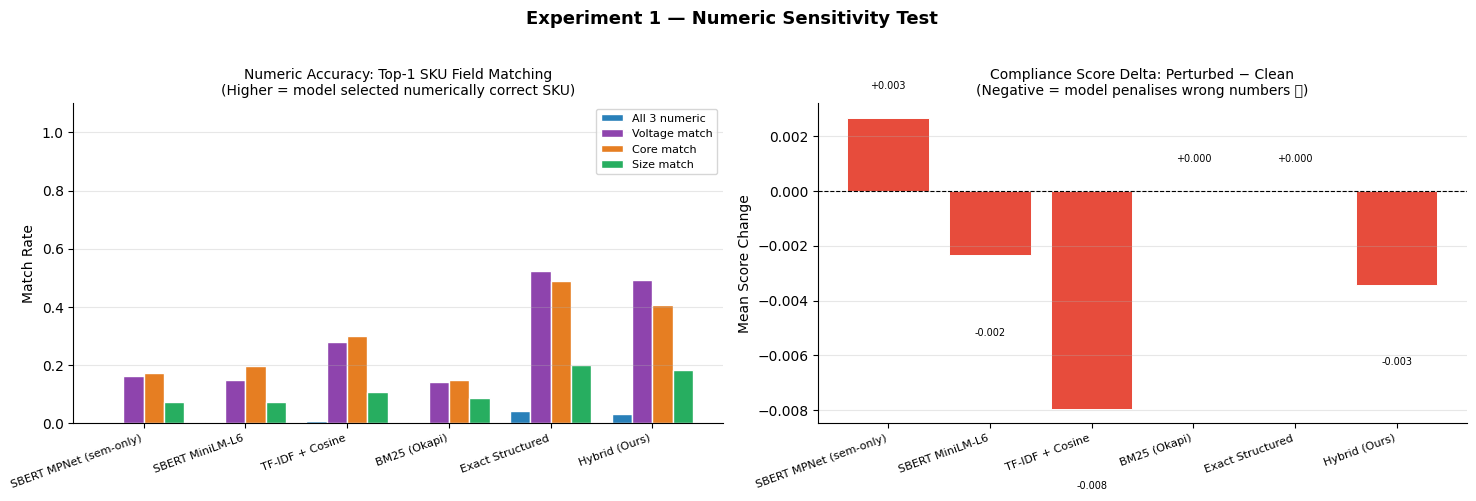

✅ Saved exp1_numeric_accuracy.png


In [ ]:
# ============================================================
# CELL 11 — VISUALISATION 1: NUMERIC ACCURACY BAR CHART
# The core "SBERT fails, Hybrid succeeds" plot
# ============================================================
fig, axes = plt.subplots(1, 2, figsize=(15, 5))
models_ordered = [r['Model'] for r in summary_rows]
colors = ['#e74c3c' if 'Hybrid' not in m else '#2ecc71' for m in models_ordered]

# ── Plot 1: Numeric Accuracy ─────────────────────────────────
num_acc  = [r['Numeric Acc (all 3)'] for r in summary_rows]
v_acc    = [r['Voltage Match %']     for r in summary_rows]
c_acc    = [r['Core Match %']        for r in summary_rows]
s_acc    = [r['Size Match %']        for r in summary_rows]

x = np.arange(len(models_ordered))
w = 0.20
axes[0].bar(x-1.5*w, num_acc, w, label='All 3 numeric',  color='#2980b9', edgecolor='white')
axes[0].bar(x-0.5*w, v_acc,   w, label='Voltage match',  color='#8e44ad', edgecolor='white')
axes[0].bar(x+0.5*w, c_acc,   w, label='Core match',     color='#e67e22', edgecolor='white')
axes[0].bar(x+1.5*w, s_acc,   w, label='Size match',     color='#27ae60', edgecolor='white')

axes[0].set_xticks(x)
axes[0].set_xticklabels([m.replace('🏆 ','') for m in models_ordered], rotation=20, ha='right', fontsize=8)
axes[0].set_title('Numeric Accuracy: Top-1 SKU Field Matching\n(Higher = model selected numerically correct SKU)', fontsize=10)
axes[0].set_ylabel('Match Rate')
axes[0].set_ylim(0, 1.1)
axes[0].legend(fontsize=8)
axes[0].grid(axis='y', alpha=0.3)
axes[0].spines[['top','right']].set_visible(False)

# ── Plot 2: Compliance Drop (score sensitivity) ───────────────
comp_drop = [r['Compliance Drop %'] for r in summary_rows]
avg_delta = [r['Avg Score Delta']   for r in summary_rows]

ax2 = axes[1]
bar_colors = ['#2ecc71' if v < -0.01 else '#e74c3c' for v in avg_delta]
bars = ax2.bar(x, avg_delta, color=bar_colors, edgecolor='white', linewidth=0.7)

for bar, val in zip(bars, avg_delta):
    ax2.text(bar.get_x()+bar.get_width()/2,
             bar.get_height() + (0.001 if val >= 0 else -0.003),
             f'{val:+.3f}', ha='center', va='bottom', fontsize=7)

ax2.axhline(0, color='black', linewidth=0.8, linestyle='--')
ax2.set_xticks(x)
ax2.set_xticklabels([m.replace('🏆 ','') for m in models_ordered], rotation=20, ha='right', fontsize=8)
ax2.set_title('Compliance Score Delta: Perturbed − Clean\n(Negative = model penalises wrong numbers ✅)', fontsize=10)
ax2.set_ylabel('Mean Score Change')
ax2.grid(axis='y', alpha=0.3)
ax2.spines[['top','right']].set_visible(False)

plt.suptitle('Experiment 1 — Numeric Sensitivity Test', fontsize=13, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig(f'{EXP_DIR}/exp1_numeric_accuracy.png', dpi=150, bbox_inches='tight')
plt.show()
print('✅ Saved exp1_numeric_accuracy.png')

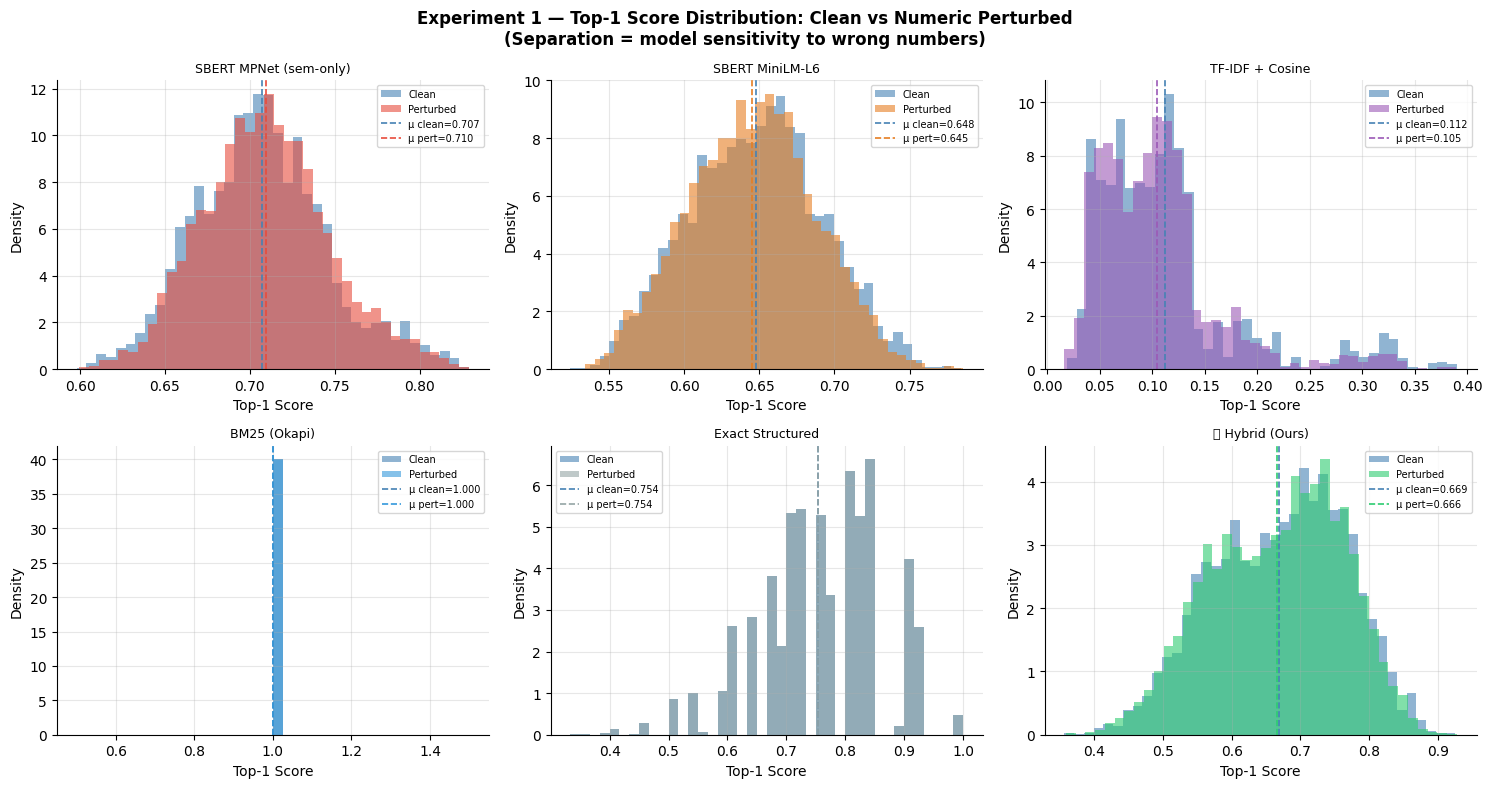

✅ Saved exp1_score_distributions.png


In [ ]:
# ============================================================
# CELL 12 — VISUALISATION 2: DEGRADATION CURVES
# Score distribution Clean vs Perturbed per model
# ============================================================
fig, axes = plt.subplots(2, 3, figsize=(15, 8))
axes = axes.flatten()

plot_models = [
    ('SBERT MPNet (sem-only)', 'semantic',  '#e74c3c'),
    ('SBERT MiniLM-L6',        'minilm',   '#e67e22'),
    ('TF-IDF + Cosine',        'tfidf',    '#9b59b6'),
    ('BM25 (Okapi)',           'bm25',     '#3498db'),
    ('Exact Structured',       'structured','#95a5a6'),
    ('🏆 Hybrid (Ours)',       'hybrid',   '#2ecc71'),
]

for ax, (model_name, score_key, color) in zip(axes, plot_models):
    # The problematic 'clean_scores' assignment was removed as it was redundant
    # and caused the IndexError due to chained column selection.
    # 'clean_top1' and 'pert_top1' are correctly computed below.

    col_map = {'semantic':'Semantic_Score','minilm':'MiniLM_Score','tfidf':'TFIDF_Score',
               'bm25':'BM25_Score','structured':'Structured_Score','hybrid':'Hybrid_Score'}
    col = col_map[score_key]

    clean_top1 = match_clean.groupby('RFP_ID')[col].max().values
    pert_top1  = match_pert.groupby('RFP_ID')[col].max().values

    ax.hist(clean_top1, bins=40, alpha=0.6, color='steelblue', label='Clean', density=True)
    ax.hist(pert_top1,  bins=40, alpha=0.6, color=color,       label='Perturbed', density=True)
    ax.axvline(clean_top1.mean(), color='steelblue', linestyle='--', linewidth=1.2,
               label=f'μ clean={clean_top1.mean():.3f}')
    ax.axvline(pert_top1.mean(),  color=color,       linestyle='--', linewidth=1.2,
               label=f'μ pert={pert_top1.mean():.3f}')
    ax.set_title(model_name.replace('🏆 ','🏆 '), fontsize=9)
    ax.set_xlabel('Top-1 Score'); ax.set_ylabel('Density')
    ax.legend(fontsize=7); ax.grid(alpha=0.3)
    ax.spines[['top','right']].set_visible(False)

plt.suptitle('Experiment 1 — Top-1 Score Distribution: Clean vs Numeric Perturbed\n'
             '(Separation = model sensitivity to wrong numbers)', fontsize=12, fontweight='bold')
plt.tight_layout()
plt.savefig(f'{EXP_DIR}/exp1_score_distributions.png', dpi=150, bbox_inches='tight')
plt.show()
print('✅ Saved exp1_score_distributions.png')


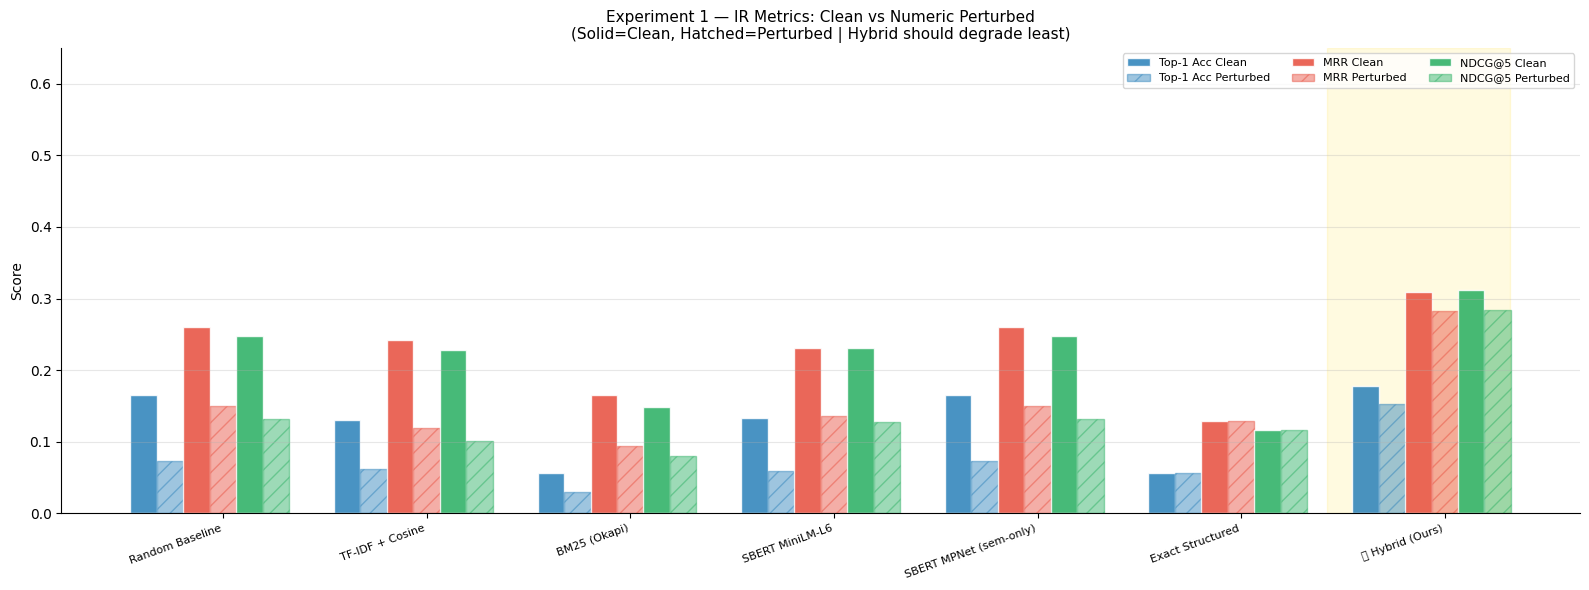

✅ Saved exp1_ir_metrics_comparison.png


In [ ]:
# ============================================================
# CELL 13 — VISUALISATION 3: CLEAN vs PERT METRICS COMPARISON
# Grouped bar: Clean (solid) vs Perturbed (hatched)
# ============================================================
plot_metric_pairs = [
    ('Top-1 (Clean)','Top-1 (Pert)','Top-1 Acc'),
    ('MRR (Clean)',  'MRR (Pert)',  'MRR'),
    ('NDCG@5 (Clean)','NDCG@5 (Pert)','NDCG@5'),
]
models_plot = metrics_df['Model'].tolist()
x = np.arange(len(models_plot))
w = 0.13

fig, ax = plt.subplots(figsize=(16, 6))
palette = ['#2980b9','#e74c3c','#27ae60']

for k, (col_c, col_p, label) in enumerate(plot_metric_pairs):
    offset = (k - 1) * 2 * w
    ax.bar(x + offset,       metrics_df[col_c].values, w, color=palette[k],
           alpha=0.85, edgecolor='white', label=f'{label} Clean')
    ax.bar(x + offset + w,   metrics_df[col_p].values, w, color=palette[k],
           alpha=0.45, edgecolor=palette[k], hatch='//', label=f'{label} Perturbed')

# Hybrid highlight
hybrid_x = [i for i, m in enumerate(models_plot) if 'Hybrid' in m][0]
ax.axvspan(hybrid_x - 0.45, hybrid_x + 0.45, color='gold', alpha=0.12, zorder=0)

ax.set_xticks(x + w)
ax.set_xticklabels(models_plot, rotation=20, ha='right', fontsize=8)
ax.set_ylabel('Score')
ax.set_ylim(0, 0.65)
ax.set_title('Experiment 1 — IR Metrics: Clean vs Numeric Perturbed\n'
             '(Solid=Clean, Hatched=Perturbed | Hybrid should degrade least)', fontsize=11)
ax.legend(fontsize=8, ncol=3, loc='upper right')
ax.grid(axis='y', alpha=0.3)
ax.spines[['top','right']].set_visible(False)

plt.tight_layout()
plt.savefig(f'{EXP_DIR}/exp1_ir_metrics_comparison.png', dpi=150, bbox_inches='tight')
plt.show()
print('✅ Saved exp1_ir_metrics_comparison.png')

In [ ]:
# ============================================================
# CELL 14 — VISUALISATION 4: SBERT FAILURE CASE ANALYSIS
# Show specific examples where SBERT assigns high similarity
# to numerically wrong matches
# ============================================================
print('=== SBERT Failure Case Analysis ===\n')
print('Cases where SBERT gives HIGH semantic similarity (>0.7) to a WRONG numeric match:\n')

sbert_sub = na_df[na_df['model'] == 'SBERT MPNet (sem-only)']
hybrid_sub = na_df[na_df['model'] == '🏆 Hybrid (Ours)']

# Find RFPs where SBERT top-1 has wrong voltage but high score
sbert_fail = sbert_sub[
    (~sbert_sub['voltage_match']) &
    (sbert_sub['score_pert'] > 0.7)
].head(8)

print(f'SBERT failures (wrong voltage, score > 0.7): {len(sbert_fail)} RFPs\n')

for _, row in sbert_fail.iterrows():
    rfp_idx  = df_clean[df_clean['rfp_id'] == row['rfp_id']].index[0]
    sku_row  = sku_lookup.loc[row['top1_pert']]
    hybrid_r = hybrid_sub[hybrid_sub['rfp_id'] == row['rfp_id']].iloc[0]

    print(f"  RFP  : {row['rfp_id']}")
    print(f"  Clean text  : {df_clean.loc[rfp_idx,'spec_text_raw']}")
    print(f"  Pert text   : {df_num.loc[rfp_idx,'spec_text_raw']}")
    print(f"  SBERT Top-1 SKU: {row['top1_pert']}  |  Score: {row['score_pert']:.4f}")
    print(f"  SKU voltage: {sku_row['voltage_rating']}  RFP voltage: {df_clean.loc[rfp_idx,'voltage_rating']}  → Match: {row['voltage_match']}")
    print(f"  Hybrid Top-1 SKU: {hybrid_r['top1_pert']}  |  Score: {hybrid_r['score_pert']:.4f}  Voltage match: {hybrid_r['voltage_match']}")
    print()

=== SBERT Failure Case Analysis ===

Cases where SBERT gives HIGH semantic similarity (>0.7) to a WRONG numeric match:

SBERT failures (wrong voltage, score > 0.7): 8 RFPs

  RFP  : RFP_0004
  Clean text  : FRLS 3.3kV 1C 50 sqmm Cu EPR armoured cable as per IS 7098-1
  Pert text   : FRLS 6.6kV 3C 50 sqmm Cu EPR armoured cable as per IS 7098-1
  SBERT Top-1 SKU: SKU_255  |  Score: 0.7127
  SKU voltage: 66kV  RFP voltage: 3.3kV  → Match: False
  Hybrid Top-1 SKU: SKU_125  |  Score: 0.7476  Voltage match: False

  RFP  : RFP_0010
  Clean text  : FR 500V 4C 4 sqmm Cu PVC armoured cable as per IS 694
  Pert text   : FR 440V 4C 2.5 sqmm Cu PVC armoured cable as per IS 694
  SBERT Top-1 SKU: SKU_220  |  Score: 0.7456
  SKU voltage: 440V  RFP voltage: 500V  → Match: False
  Hybrid Top-1 SKU: SKU_233  |  Score: 0.8117  Voltage match: False

  RFP  : RFP_0011
  Clean text  : FR 300V 24C 2.5 sqmm Cu XLPE armoured cable as per BS 5308-1
  Pert text   : FR 300V 20C 4 sqmm Cu XLPE armoured cable as 

In [ ]:
# ============================================================
# CELL 15 — FINAL SUMMARY TABLE (PAPER-READY)
# ============================================================
print('\n' + '='*105)
print('  EXPERIMENT 1 — NUMERIC SENSITIVITY TEST: COMPLETE RESULTS SUMMARY')
print('='*105)

final_summary = summary_df[[
    'Model', 'Numeric Acc (all 3)', 'Voltage Match %', 'Core Match %',
    'Size Match %', 'Compliance Drop %', 'Avg Score Delta'
]].copy()

print('\n── Section A: Numeric Accuracy ──')
print(final_summary.to_markdown(index=False, floatfmt='.4f'))

print('\n── Section B: IR Metrics (Clean → Perturbed) ──')
print(metrics_df[['Model','Top-1 (Clean)','Top-1 (Pert)','Δ Top-1',
                   'MRR (Clean)','MRR (Pert)','Δ MRR',
                   'NDCG@5 (Clean)','NDCG@5 (Pert)','Δ NDCG@5']]
      .to_markdown(index=False, floatfmt='.4f'))

# Key takeaway
hybrid_row  = metrics_df[metrics_df['Model'].str.contains('Hybrid')].iloc[0]
sbert_row   = metrics_df[metrics_df['Model'].str.contains('MPNet')].iloc[0]

print('\n── Key Findings ──')
print(f'  SBERT MPNet  Top-1 degradation: {sbert_row["Δ Top-1"]:+.4f}  '
      f'({sbert_row["Δ Top-1"]/sbert_row["Top-1 (Clean)"]*100:+.1f}%)')
print(f'  Hybrid       Top-1 degradation: {hybrid_row["Δ Top-1"]:+.4f}  '
      f'({hybrid_row["Δ Top-1"]/hybrid_row["Top-1 (Clean)"]*100:+.1f}%)')
print(f'  SBERT MRR    degradation: {sbert_row["Δ MRR"]:+.4f}')
print(f'  Hybrid MRR   degradation: {hybrid_row["Δ MRR"]:+.4f}')

hybrid_num = summary_df[summary_df['Model'].str.contains('Hybrid')].iloc[0]
sbert_num  = summary_df[summary_df['Model'].str.contains('MPNet')].iloc[0]
print(f'\n  SBERT Numeric Acc (all 3 fields): {sbert_num["Numeric Acc (all 3)"]:.4f}')
print(f'  Hybrid Numeric Acc (all 3 fields): {hybrid_num["Numeric Acc (all 3)"]:.4f}')
print(f'  → Hybrid numeric advantage: {hybrid_num["Numeric Acc (all 3)"] - sbert_num["Numeric Acc (all 3)"]:+.4f}')
print(f'\n  SBERT Compliance Drop %: {sbert_num["Compliance Drop %"]:.4f}')
print(f'  Hybrid Compliance Drop %: {hybrid_num["Compliance Drop %"]:.4f}')
print(f'  → A higher Compliance Drop % = model correctly penalises wrong numbers')


  EXPERIMENT 1 — NUMERIC SENSITIVITY TEST: COMPLETE RESULTS SUMMARY

── Section A: Numeric Accuracy ──
| Model                  |   Numeric Acc (all 3) |   Voltage Match % |   Core Match % |   Size Match % |   Compliance Drop % |   Avg Score Delta |
|:-----------------------|----------------------:|------------------:|---------------:|---------------:|--------------------:|------------------:|
| SBERT MPNet (sem-only) |                0.0020 |            0.1614 |         0.1743 |         0.0733 |              0.4597 |            0.0027 |
| SBERT MiniLM-L6        |                0.0036 |            0.1490 |         0.1963 |         0.0714 |              0.5573 |           -0.0024 |
| TF-IDF + Cosine        |                0.0091 |            0.2780 |         0.3000 |         0.1087 |              0.5609 |           -0.0079 |
| BM25 (Okapi)           |                0.0033 |            0.1411 |         0.1501 |         0.0879 |              0.0000 |            0.0000 |
| Exact Struct

In [ ]:
# ============================================================
# CELL 16 — EXPORT ALL RESULTS
# ============================================================
summary_df.to_csv(f'{EXP_DIR}/exp1_numeric_accuracy_summary.csv', index=False)
metrics_df.to_csv(f'{EXP_DIR}/exp1_ir_metrics_clean_vs_pert.csv', index=False)
na_df.to_csv(f'{EXP_DIR}/exp1_per_rfp_analysis.csv', index=False)

print('✅ Saved:')
for f in sorted(os.listdir(EXP_DIR)):
    print(f'   {EXP_DIR}/{f}')

✅ Saved:
   exp1_numeric_sensitivity/exp1_ir_metrics_clean_vs_pert.csv
   exp1_numeric_sensitivity/exp1_ir_metrics_comparison.png
   exp1_numeric_sensitivity/exp1_numeric_accuracy.png
   exp1_numeric_sensitivity/exp1_numeric_accuracy_summary.csv
   exp1_numeric_sensitivity/exp1_per_rfp_analysis.csv
   exp1_numeric_sensitivity/exp1_score_distributions.png
